###1) Статистика ChIP BAM

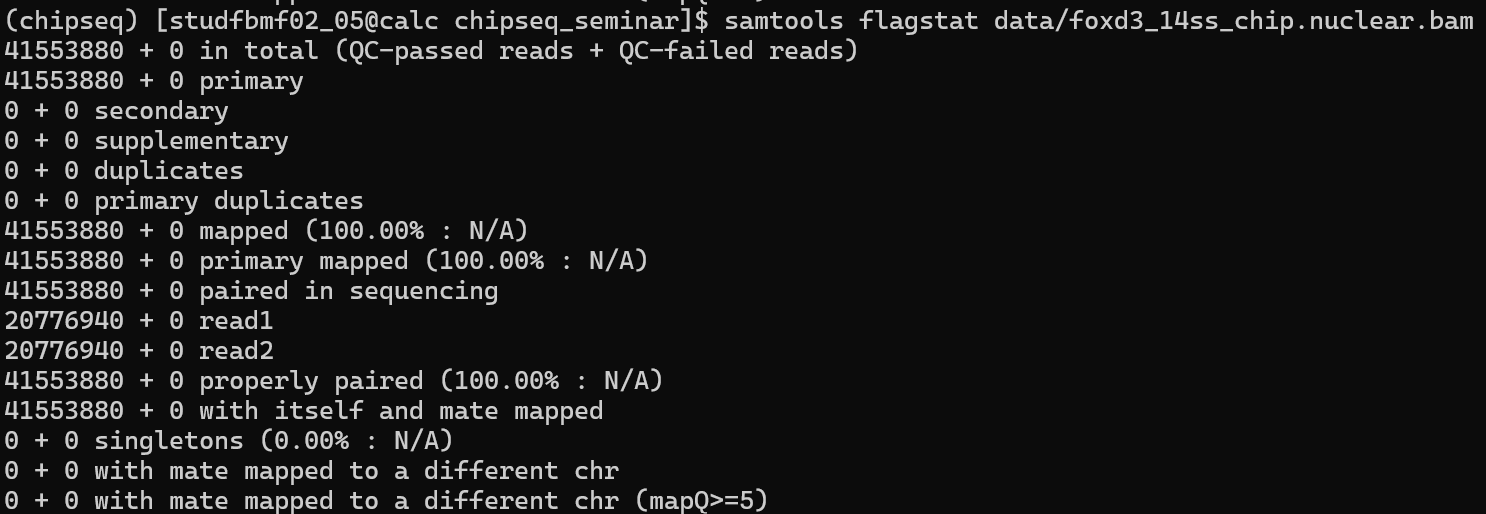

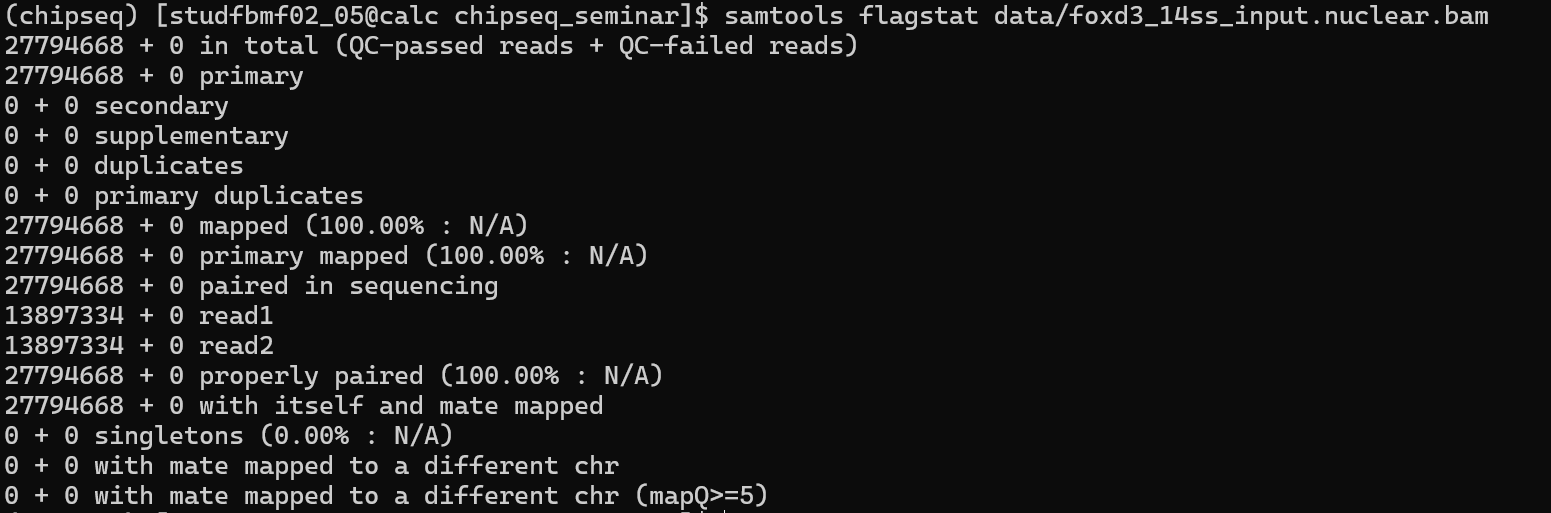

При сравнении двух типов данных видна ожидаемая разница в глубине секвенирования, тк для достоверного построения пиков ChIP секвенируют чуть глубже

###2) Число пиков

Строим покрытие СhIP и Input, рассчитываем обогащение и смотрим число пиков

In [ ]:
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ wc -l results/peaks/foxd3_14ss_peaks.narrowPeak
170 results/peaks/foxd3_14ss_peaks.narrowPeak

*  Можно ли число вызванных peaks напрямую считать числом сайтов связывания Foxd3?

Нет. MACS3 при заданных параметрах (-q 0.01) выявил 170 участков, в которых сигнал ChIP статистически значимо превышает локальный фон - это список только кандидатных регионов. Число пиков может одновременно занижать (непрохождение порога значимости, близкорасположенные сайты) и завышать (непрямое связывание foxd3 с днк через другой белок, мб какие-то артефакты) реальное количество сайтов

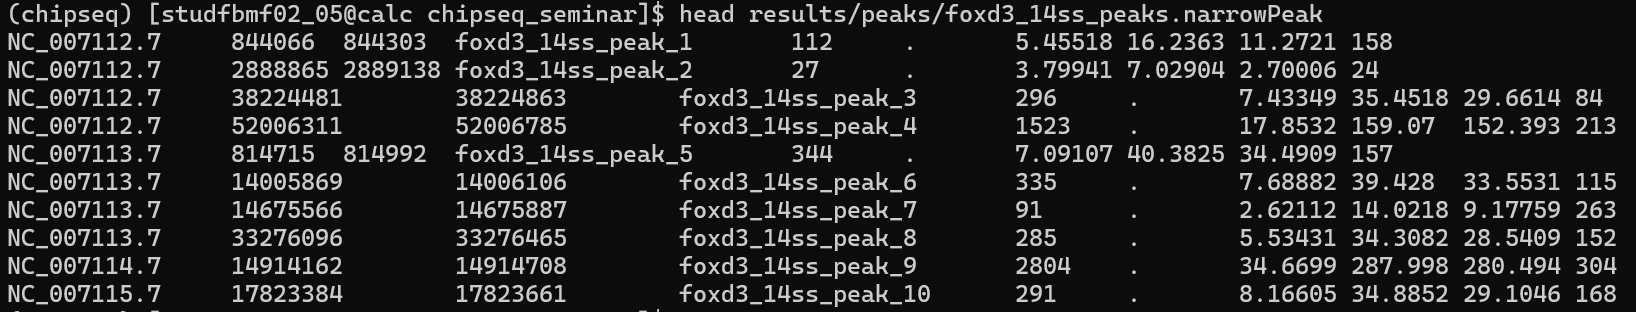

Столбцы:

1 - RefSeq-идентификаторы хромосом

2,3 - позиции начала и конца пика

4 - название

5 - score для визуализации

6 - цепь

7 - кратность обогащения

8 - −log10(p-value)

9 - 	−log10(q-value)

10 - смещение вершины пика от его начала

###3) Наиболее значимые пики

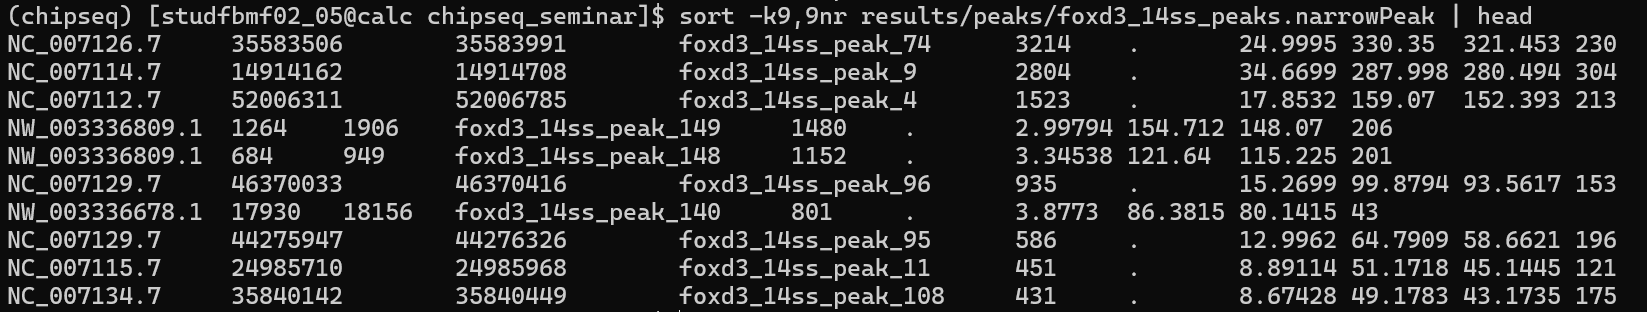

Сортируем по 9 колонке (−log10(q-value)), те значимость с поправкой на множественное тестирование

Самый значимый пик foxd3_14ss_peak_74:

$$-lg(q) = 321,453$$

$$q = 10^{-321,453}$$



###4) FRiP

alignments в ChIP = 41553880

alignments внутри пиков = 67346

FRiP = 67346/41553880 = 0,0016 = 0,16%

###5) HeatMap

Для каждого пика берем окно ±2 кб вокруг его вершины и смотрим, как в нём ведёт себя сигнал ChIP и input. Получаем матрицу для последующего построения heatmap

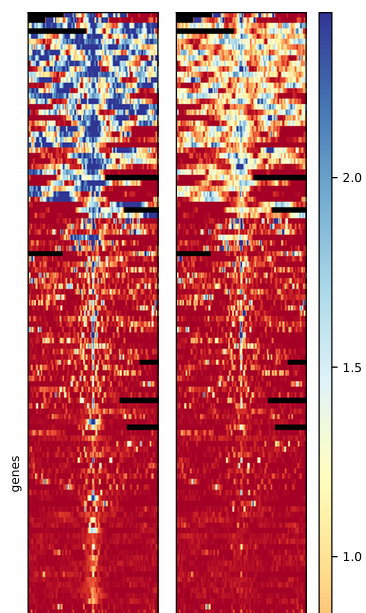

График усредненного профиля (берем 170 вершин пиков, накладываем их друг на друга по центру и усредняем покрытие в каждой позиции)

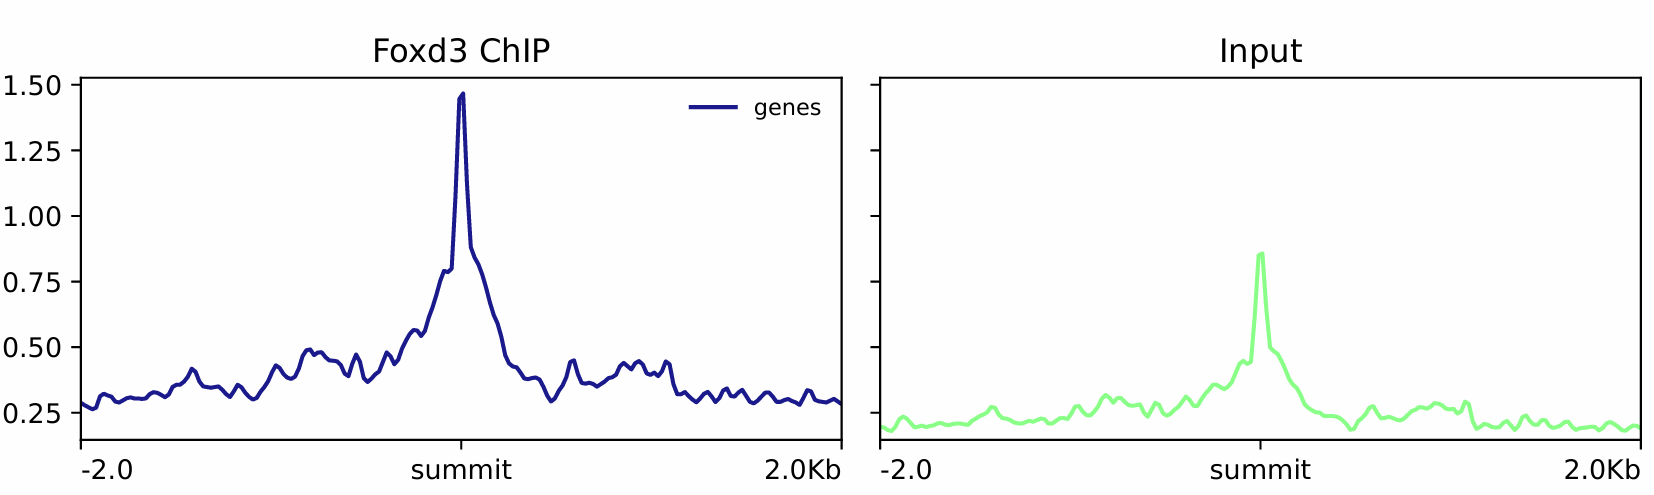

 ChIP профиль демонстрирует резкий пик, что соответствует ожидаемому паттерну для точечно связывающегося транскрипционного фактора

Для Input также можно наблюдать маленький пик, скорее всего это связано с характеристикой днк при подготовке бибилиотеки. Открытые участки, представляющие собой регуляторные элементы (промоторы, энхансеры) куда садится наш foxd3, фрагментируются охотнее окружения, тем самым дают больше ридов

###6) Сравнение пиков

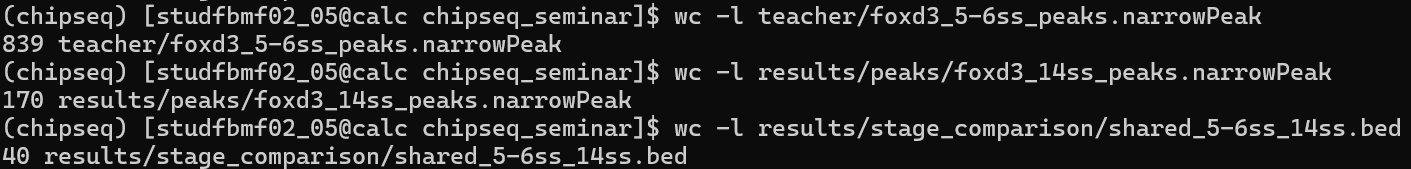

На стадии 5–6ss выявлено 839 пиков, на 14ss - 170. Пересечение составило 40 регионов: 4,8% от набора 5–6ss и 23,5% от набора 14ss

Сокращение числа пиков и низкое перекрытие в обоих направлениях указывают на существенную перестройку репертуара связывания foxd3. Большая часть сайтов, занятых на 5–6ss, не выявляется на 14ss, при этом около трёх четвертей поздних сайтов не были заняты ранее , те это замена исходного набора, что согласуется с описанной сменой функции foxd3 с пионерной на репрессорную

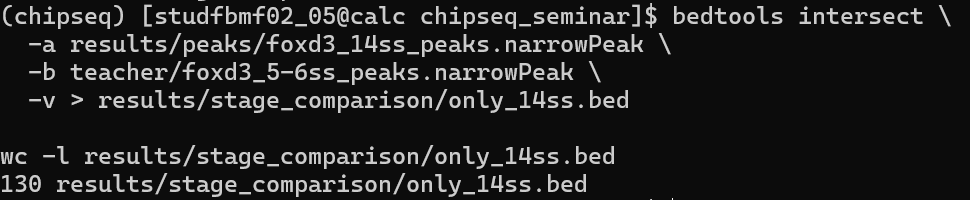

Три четверти поздних сайтов - новые, это подтверждает что  репертуар  перестраивается

Если бы foxd3 к 14ss просто терял часть мишеней, поздний набор был бы подмножеством раннего, и доля общих от 170 приближалась бы к 100%, но у нас 23,5%